# 2. The rows that repeat

**Week 1, Wednesday. Chapter 2 of 6.** Chapter 1 profiled the export: 201 rows, 186 distinct ids, one amount that does not convert, and Q1 at Rs 2,09,98,210 over the amounts that do. This chapter decides what makes two rows one order.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail


    **The need.** Q1 as exported is Rs 2,09,98,210 and the books say Rs 1,90,00,000. The ERP team's
    note says the CSV was stitched from two extracts during the Q1 migration, and the profile found
    201 rows for 186 order ids. If orders were exported twice, Q1 revenue and Q1 order counts are
    both inflated, and so is every per-customer rate Tuesday computed. Anand's question is which
    rows repeat; answering it wrongly either keeps Rs 20 lakh that was never earned or deletes real
    orders from the books.

    **Who else faces it.** On 22 and 23 May 2009 a processing fault at Starbucks billed some card customers twice across about 7,800 company-owned stores in the US and Canada, and the company repaid about one million customers (NBC News and AP, 10 June 2009, checked 30 Sep 2026). The same purchase recorded twice looks like two purchases until someone asks what makes two records one.


Kalpa Retail's business, its metrics and who decides what are in the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`; this notebook assumes it.

**Setup.** The helper and chapter 1's tools, so this notebook starts where chapter 1 ended.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

raw = read_orders()
print(len(raw), "rows;", len({r["order_id"] for r in raw}), "distinct order ids")

201 rows; 186 distinct order ids


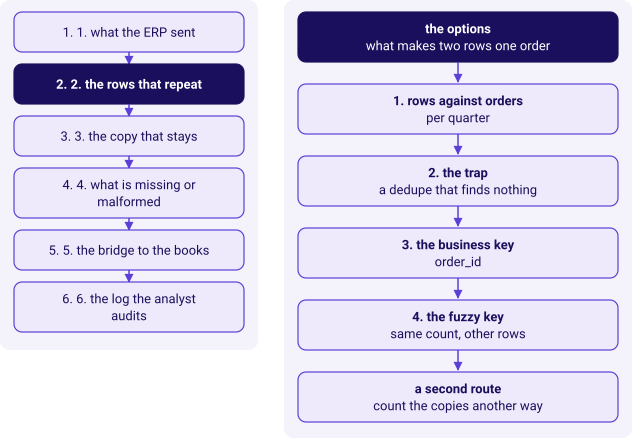

In [2]:
kit.side_by_side(
    kit.ladder(["1. what the ERP sent", "2. the rows that repeat", "3. the copy that stays", "4. what is missing or malformed", "5. the bridge to the books", "6. the log the analyst audits"], lit=1, show=False),
    kit.vflow(["the options\nwhat makes two rows one order", "1. rows against orders\nper quarter", "2. the trap\na dedupe that finds nothing", "3. the business key\norder_id", "4. the fuzzy key\nsame count, other rows", "a second route\ncount the copies another way"], lit=0, show=False),
)

## The options

| Option | Two rows are the same when | Where it comes from |
|---|---|---|
| a) The whole record | every field matches, as the rows now stand | Most tools' default dedupe |
| b) The whole record less the line | every field but the file line matches | The first fix people reach for |
| c) The business key | `order_id` matches | The ERP issues one id per order |
| d) A fuzzy key | same customer and same amount | Record linkage when no key can be trusted |

**Predict before you run.** Which options will flag the same number of rows as c? a) none;
b) only b; c) only d; d) b and d.

key,rows flagged,Q1 after,Q2 after,copies missed,real rupees removed,work
a) whole record,0,"Rs 2,09,98,210","Rs 1,87,03,710",15,Rs 0,201 lookups
b) whole record less line,13,"Rs 1,90,00,000","Rs 1,87,03,710",2,Rs 0,201 lookups
c) order_id,15,"Rs 1,90,00,000","Rs 1,87,00,000",0,Rs 0,201 lookups
d) customer and amount,15,"Rs 1,90,00,000","Rs 1,69,29,000",1,"Rs 17,71,000","20,100 pairs"


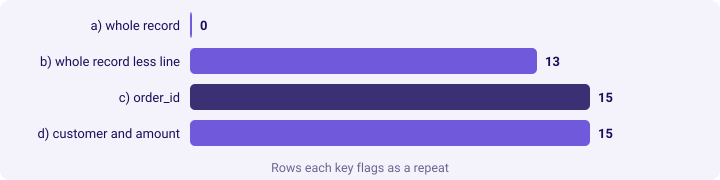

In [3]:
def flagged_by(rows, keyf):
    """The rows a key calls repeats; within a group the copy whose amount converts stays, as chapter 3 argues."""
    first, out = {}, []
    for r in rows:
        k = keyf(r)
        if k not in first:
            first[k] = r
        elif convert(first[k]["amount"])[0] is None and convert(r["amount"])[0] is not None:
            out.append(first[k]); first[k] = r
        else:
            out.append(r)
    return out

KEYS = {
    "a) whole record": lambda r: tuple(sorted(r.items())),
    "b) whole record less line": lambda r: tuple(sorted((k, v) for k, v in r.items() if k != "line")),
    "c) order_id": lambda r: r["order_id"],
    "d) customer and amount": lambda r: (r["customer_id"], r["amount"]),
}
by_key = {name: flagged_by(raw, f) for name, f in KEYS.items()}
truth = {r["line"] for r in by_key["c) order_id"]}
rows_out = []
for name, flagged in by_key.items():
    lines = {r["line"] for r in flagged}
    kept = [r for r in raw if r["line"] not in lines]
    wrong = [r for r in flagged if r["line"] not in truth]
    rows_out.append((name, len(flagged), kit.rupees(Q(kept, "Q1")), kit.rupees(Q(kept, "Q2")),
                     len(truth - lines), kit.rupees(sum(convert(r["amount"])[0] or 0 for r in wrong)),
                     "20,100 pairs" if name.startswith("d") else "201 lookups"))
kit.table(["key", "rows flagged", "Q1 after", "Q2 after", "copies missed", "real rupees removed", "work"],
          rows_out, caption="Each key sized on the ERP file; 'copies missed' is measured against the order_id key")
kit.bars([(n, len(f)) for n, f in by_key.items()], lit=(2,), title="Rows each key flags as a repeat")

**What happened.** The answer is c: the fuzzy key flags 15 rows, as many as the order id, and they
are not the same 15. It removes one real Business order worth Rs 17,71,000, placed by a customer
who spent the same amount again the next quarter, and it misses a pair whose amounts differ. The
whole record flags nothing, and the whole record less the line flags 13 and misses two pairs.
The fuzzy key also costs the most work: without a key to group on, every row is compared with
every other, 20,100 pairs here and about 2 lakh crore on a file of 2 crore rows.

**The best-fit call: c, the order id.** The ERP issues one id per order and never reuses it, so
the id is what the business says an order is. **The fact that would change it:** two systems
issuing their own ids, the app numbering from one and the stores numbering from one. The id alone
would then merge different orders, and the key becomes the source system plus the id.

## 1. Rows against orders, quarter by quarter

**Predict before you run.** Where do rows and distinct ids part company? a) evenly; b) mostly in
Q1, the quarter of the migration; c) mostly in Q2; d) nowhere.

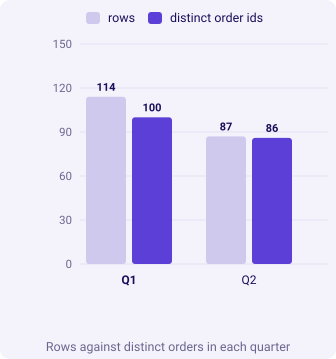

In [4]:
by_q = {}
for q in ("Q1", "Q2"):
    rows_q = [r for r in raw if r["quarter"] == q]
    by_q[q] = (len(rows_q), len({r["order_id"] for r in rows_q}))
kit.columns(["Q1", "Q2"], [("rows", [by_q["Q1"][0], by_q["Q2"][0]]),
                           ("distinct order ids", [by_q["Q1"][1], by_q["Q2"][1]])],
            lit=(0,), title="Rows against distinct orders in each quarter")
kit.check("Q1 carries 14 rows beyond one per order", by_q["Q1"][0] - by_q["Q1"][1] == 14)
kit.check("Q2 carries 1", by_q["Q2"][0] - by_q["Q2"][1] == 1)

**What happened.** The answer is b. Q1 holds 114 rows for 100 orders and Q2 holds 87 for 86, so the
extra rows sit in the quarter the migration touched, which is where the dashboard and the books
disagree. That is a lead, and the next step is to remove them.

## 2. The trap: a dedupe that reports zero duplicates

Chapter 1's rejects log cited a file line, so every record carries `line`. The hurried analyst
runs the default whole-record dedupe on those records.

**The plausible wrong answer.**

In [5]:
def whole_record_dedupe(rows):
    seen, kept = set(), []
    for r in rows:
        key = tuple(sorted(r.items()))
        if key not in seen:
            seen.add(key)
            kept.append(r)
    return kept

kept_whole = whole_record_dedupe(raw)
kit.stats([(str(len(raw) - len(kept_whole)), "duplicates found", "the whole-record dedupe"),
           (kit.rupees(Q(kept_whole, "Q1")), "Q1 revenue", "unchanged, so the dashboard looks right"),
           ("Rs 20 lakh", "left unexplained", "and the note says Finance is short")],
          caption="The hurried dedupe, as it would be reported")

**Why it is wrong.** The file line is where a row sat, not what the order is. Two copies of one
order sit on different lines, so every record is unique and the dedupe can never find anything.
The note would tell Anand his books are Rs 20 lakh short, sending Finance to hunt for revenue that
was never earned. The check is chapter 1's: 201 rows and 186 ids cannot both be true of a file
with no repeats. The mechanism, on five invented records in which two orders appear twice:

In [6]:
# Invented records, to show the mechanism without touching the ERP file.
invented = [
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2400"},
    {"order_id": "INV-02", "segment": "Retail-Core", "order_date": "2026-05-09", "amount": "1300"},
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2400"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
]
for n, r in enumerate(invented, start=2):
    r["line"] = n

found = len(invented) - len(whole_record_dedupe(invented))
without_line = [{k: v for k, v in r.items() if k != "line"} for r in invented]
found_without = len(without_line) - len(whole_record_dedupe(without_line))
kit.table(["the comparison", "repeats found in the invented five"],
          [("every field, including the file line", found),
           ("every field except the file line", found_without),
           ("the order id alone", len(invented) - len({r["order_id"] for r in invented}))],
          caption="Invented records: the file line makes every row unique")
kit.check("the whole-record dedupe reports zero on the ERP file", len(raw) - len(kept_whole) == 0)
kit.check("yet distinct order ids fall 15 short of the rows", len(raw) - len({r["order_id"] for r in raw}) == 15)
kit.check("on invented records, leaving out the line finds both copies", found == 0 and found_without == 2)

the comparison,repeats found in the invented five
"every field, including the file line",0
every field except the file line,2
the order id alone,2


## 3. The fix: the business key

**Predict before you run.** Grouped by `order_id`, how many groups hold more than one row? a) 14,
one per extra Q1 row; b) 15; c) 186; d) 201.

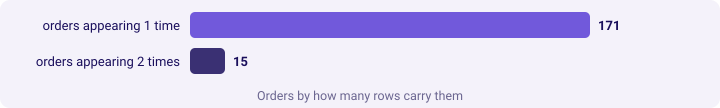

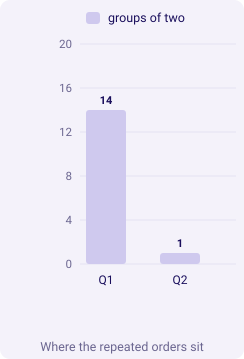

In [7]:
groups = {}
for r in raw:
    groups.setdefault(r["order_id"], []).append(r)
multi = {k: rs for k, rs in groups.items() if len(rs) > 1}
sizes = Counter(len(rs) for rs in groups.values())
kit.bars([(f"orders appearing {n} time{'s' if n > 1 else ''}", c) for n, c in sorted(sizes.items())],
         lit=(1,), title="Orders by how many rows carry them")
kit.columns(["Q1", "Q2"], [("groups of two", [sum(1 for rs in multi.values() if rs[0]["quarter"] == q) for q in ("Q1", "Q2")])],
            title="Where the repeated orders sit")
kit.check("15 orders appear twice, none three times", len(multi) == 15 and max(sizes) == 2)

**What happened.** The answer is b: 15 orders appear exactly twice, 14 in Q1 and one in Q2. Each
group of two is one order and a copy, and one row of each pair has to stay. Which one is chapter
3's question.

**Your turn.** In the empty cell, print the ids of the 15 orders and the file lines of both
copies, with `[(k, [r["line"] for r in rs]) for k, rs in multi.items()]`. Say what the second
line numbers have in common, and what that tells you about the migration.

## 4. The harder variant: the same count, other rows

**Predict before you run.** The fuzzy key flags 15 rows and the order id flags 15. How many rows do
the two sets share? a) 15; b) 14; c) 13; d) none.

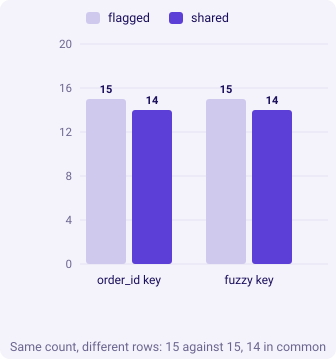

In [8]:
fuzzy = {r["line"] for r in by_key["d) customer and amount"]}
shared = fuzzy & truth
kit.columns(["order_id key", "fuzzy key"], [("flagged", [len(truth), len(fuzzy)]), ("shared", [len(shared), len(shared)])],
            title="Same count, different rows: 15 against 15, 14 in common")
kit.check("the two keys share 14 of their 15 rows", len(shared) == 14, f"{len(shared)}")
kit.check("the fuzzy key removes a real order worth Rs 17,71,000",
          sum(convert(r["amount"])[0] or 0 for r in by_key["d) customer and amount"] if r["line"] not in truth) == 1771000)

**What happened.** The answer is b. A count that matches is not a match: the two keys agree on 14
rows, and each has one the other does not. A reviewer who compared counts would have signed off
a pass that removes Rs 17,71,000 of real Q2 revenue.

## A second route: count the copies with arithmetic

The groups gave 15 repeated orders. Rows less distinct ids per quarter reaches the same number
without grouping at all.

In [9]:
arithmetic = sum(by_q[q][0] - by_q[q][1] for q in ("Q1", "Q2"))
grouped = sum(len(rs) - 1 for rs in groups.values())
kit.table(["route", "rows beyond one per order"], [("rows less distinct ids, per quarter", arithmetic),
                                                   ("groups by order_id", grouped)])
kit.check("both routes find 15 rows beyond one per order", arithmetic == grouped == 15)

route,rows beyond one per order
"rows less distinct ids, per quarter",15
groups by order_id,15


**When to switch.** The arithmetic answers how many in one line and is the check to run first on
any file. The groups answer which, and only they can feed a log.

> **Kavya's review.** "Tell me what makes two rows the same order before you tell me how many
> duplicates there are. A count of duplicates without an identity rule is a count of nothing."

### In the interview

**[F] How do you find duplicates, and what makes two records the same?** "I start with the
identity rule, not the tool. For an order that is the id the system issues; for a customer it
might be a normalised email, for a payment the gateway's reference. Then I count rows against
distinct keys. A whole-record comparison finds only exact copies, and a migration copy often
differs somewhere: a timestamp, a load id, a line number. Then I weigh them, since two rows can
carry more money than a hundred."

**[F] A dedupe returns zero duplicates. Do you believe it?** "Only after checking it against a
count of distinct keys. If rows and keys disagree, the dedupe compared on something that makes
every row unique."

**Design. Order id, whole record or fuzzy, for a customer table merged from two apps?** "Neither
app's id identifies a person across both, so the whole record and the id are out. I would
normalise email and phone and match on those, block by city to keep the comparisons in the
thousands, and send every fuzzy match a person has not confirmed to review. What would switch me
back to a key is a shared customer id issued by one system."

### Depth: when the identity rule is more than one field

Customer id and order date together is a composite key; on this file it finds 14 of the 15,
because one pair's copies disagree on the date. Record linkage across systems starts the same
way, by writing down what makes two records one before counting anything. Week 2 meets
repeated keys again in a join, where they multiply rows instead of adding them.

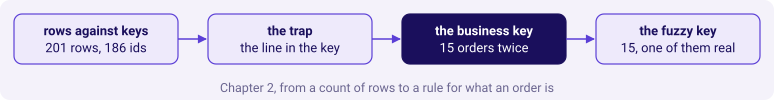

Next: chapter 3 decides which copy of each pair stays, and what that does to Q1 to the rupee.


In [10]:
kit.flow(["rows against keys\n201 rows, 186 ids", "the trap\nthe line in the key",
          "the business key\n15 orders twice", "the fuzzy key\n15, one of them real"], lit=2,
         title="Chapter 2, from a count of rows to a rule for what an order is")
kit.check_summary()
print("Next: chapter 3 decides which copy of each pair stays, and what that does to Q1 to the rupee.")